# Bayes Rules

## Chapter 8. Posterior Inference and Prediction

Code adapted from: https://github.com/pymc-devs/pymc-resources/tree/main/Bayes_Rules

Antonio Esteves @ UMinho

![](BayesRules-book-cover.png)


In [161]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pyreadr
import requests
import seaborn as sns

from plotnine import (
    aes,
    after_stat,
    geom_histogram,
    geom_line,
    ggplot,
    labs,
    stat_function,
)
from scipy import integrate
from scipy.stats import beta, binom, norm, uniform

%config InlineBackend.figure_format = 'retina'
%load_ext watermark
%load_ext nb_black
    
RANDOM_SEED = 1301
np.random.seed(RANDOM_SEED)
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-darkgrid")

The watermark extension is already loaded. To reload it, use:
  %reload_ext watermark
The nb_black extension is already loaded. To reload it, use:
  %reload_ext nb_black


<IPython.core.display.Javascript object>

Let $\pi$ denote the proportion of artists represented in major US modern art museums that are Gen X or younger. The $Beta(4,6)$ prior model for $\pi$, shown in the figure generated below, reflects our vague prior assumption that major modern art museums disproportionately display artists born before 1965, i.e., $\pi$ most likely falls below 0.5. To learn more about $\pi$, we will examine $n$=100 artists sampled from the MoMA collection. The `moma_sample.rda` dataset that we will use is a subset of data made available by MoMA.

In [20]:
def plot_beta_binomial(
    a, b, y=None, n=None, prior=True, likelihood=True, posterior=True
    ) -> None:
    '''
    Plot a Beta-Binomial Bayesian Model

    @param alpha,beta positive shape parameters of the prior Beta model
    @param y observed number of successes
    @param n observed number of trials
    @param prior a logical value indicating whether the prior model should be plotted
    @param likelihood a logical value indicating whether the scaled likelihood should be plotted
    @param posterior a logical value indicating whether posterior model should be plotted
    '''

    if y is None or n is None:
        print("Warning: to visualize the posterior specify function parameters y and n")

    theta           = np.linspace(0, 1, 100)
    p_theta_given_y = beta.pdf(theta, a, b)
    plt.fill_between(theta, p_theta_given_y, lw=2, color="k", label=f"prior for $\pi$ - Beta({a},{b})", alpha=0.2)

    likelihood   = binom.pmf(y, n, theta)
    scale_factor = integrate.simpson(likelihood, theta)
    plt.fill_between(
        theta,
        likelihood / scale_factor,
        lw = 2,
        color = "b",
        label = f"normalized likelihood - Binom({n},{y},$\pi$)/p(y)",
        alpha = 0.2,
    )

    alpha_post      = a + y
    beta_post       = b + n - y
    p_theta_given_y_post = beta.pdf(theta, alpha_post, beta_post)
    plt.fill_between(
        theta, p_theta_given_y_post, lw=2, color="r", label=f"posterior - Beta({alpha_post},{beta_post})", alpha=0.2
    )

    plt.xlabel(r"$\pi$")
    plt.ylabel("density")
    plt.legend()

<IPython.core.display.Javascript object>

In [3]:
result = pyreadr.read_r("../data/moma_sample.rda")

<IPython.core.display.Javascript object>

In [7]:
print(type(result))

print(result)

<class 'collections.OrderedDict'>
OrderedDict([('moma_sample',                  artist    country birth death  alive   genx  gender  count  \
0          Ad Gerritsen      dutch  1940  2015  False  False    male      1   
1   Kirstine Roepstorff     danish  1972   NaN   True   True  female      3   
2      Lisa Baumgardner   american  1958  2015  False  False  female      2   
3           David Bates   american  1952   NaN   True  False    male      1   
4            Simon Levy   american  1946   NaN   True  False    male      1   
..                  ...        ...   ...   ...    ...    ...     ...    ...   
95      AndrÃ© Marchand     french  1907  1997  False  False    male      1   
96          SanlÃ© Sory  burkinabe  1943   NaN   True  False    male     26   
97         Claude Monet     french  1840  1926  False  False    male      5   
98       Jean L'Anselme     french  1919  2011  False  False    male      7   
99        G. de Latenay     french  1859  1943  False  False    male

<IPython.core.display.Javascript object>

In [8]:
df = result["moma_sample"]
print(df)

                 artist    country birth death  alive   genx  gender  count  \
0          Ad Gerritsen      dutch  1940  2015  False  False    male      1   
1   Kirstine Roepstorff     danish  1972   NaN   True   True  female      3   
2      Lisa Baumgardner   american  1958  2015  False  False  female      2   
3           David Bates   american  1952   NaN   True  False    male      1   
4            Simon Levy   american  1946   NaN   True  False    male      1   
..                  ...        ...   ...   ...    ...    ...     ...    ...   
95      AndrÃ© Marchand     french  1907  1997  False  False    male      1   
96          SanlÃ© Sory  burkinabe  1943   NaN   True  False    male     26   
97         Claude Monet     french  1840  1926  False  False    male      5   
98       Jean L'Anselme     french  1919  2011  False  False    male      7   
99        G. de Latenay     french  1859  1943  False  False    male      1   

   year_acquired_min year_acquired_max  
0         

<IPython.core.display.Javascript object>

Among the sampled artists, $Y$=14 are Gen X or younger:

In [5]:
df.groupby("genx")["artist"].count()

genx
False    86
True     14
Name: artist, dtype: int64

<IPython.core.display.Javascript object>

Recognizing that the dependence of $Y$ on $\pi$ follows a Binomial model, our analysis follows the Beta-Binomial framework. Thus, our updated posterior model of $\pi$ in light of the observed art data is as follows:

$Y \mid \pi \sim Binom(100,\pi)$ (likelihood)<P>
$\pi \sim Beta(4,6$ (prior for $\pi$)<P>
$\pi \mid Y=14 \sim Beta(18,92)$ (posterior)<P>

With corresponding posterior PDF:

$f(\pi \mid Y=14) = \frac{\Gamma(18+92)}{\Gamma(18)\Gamma(92)} \pi^{18-1} (i-\pi)^{92-1}$ for $\pi \in [0,1]$

The evolution in our understanding of $\pi$ is shown in the figure generated below. Whereas we started with a vague understanding that under half of displayed artists are Gen X, the data gave us some certainty that this figure likely falls below 25%.

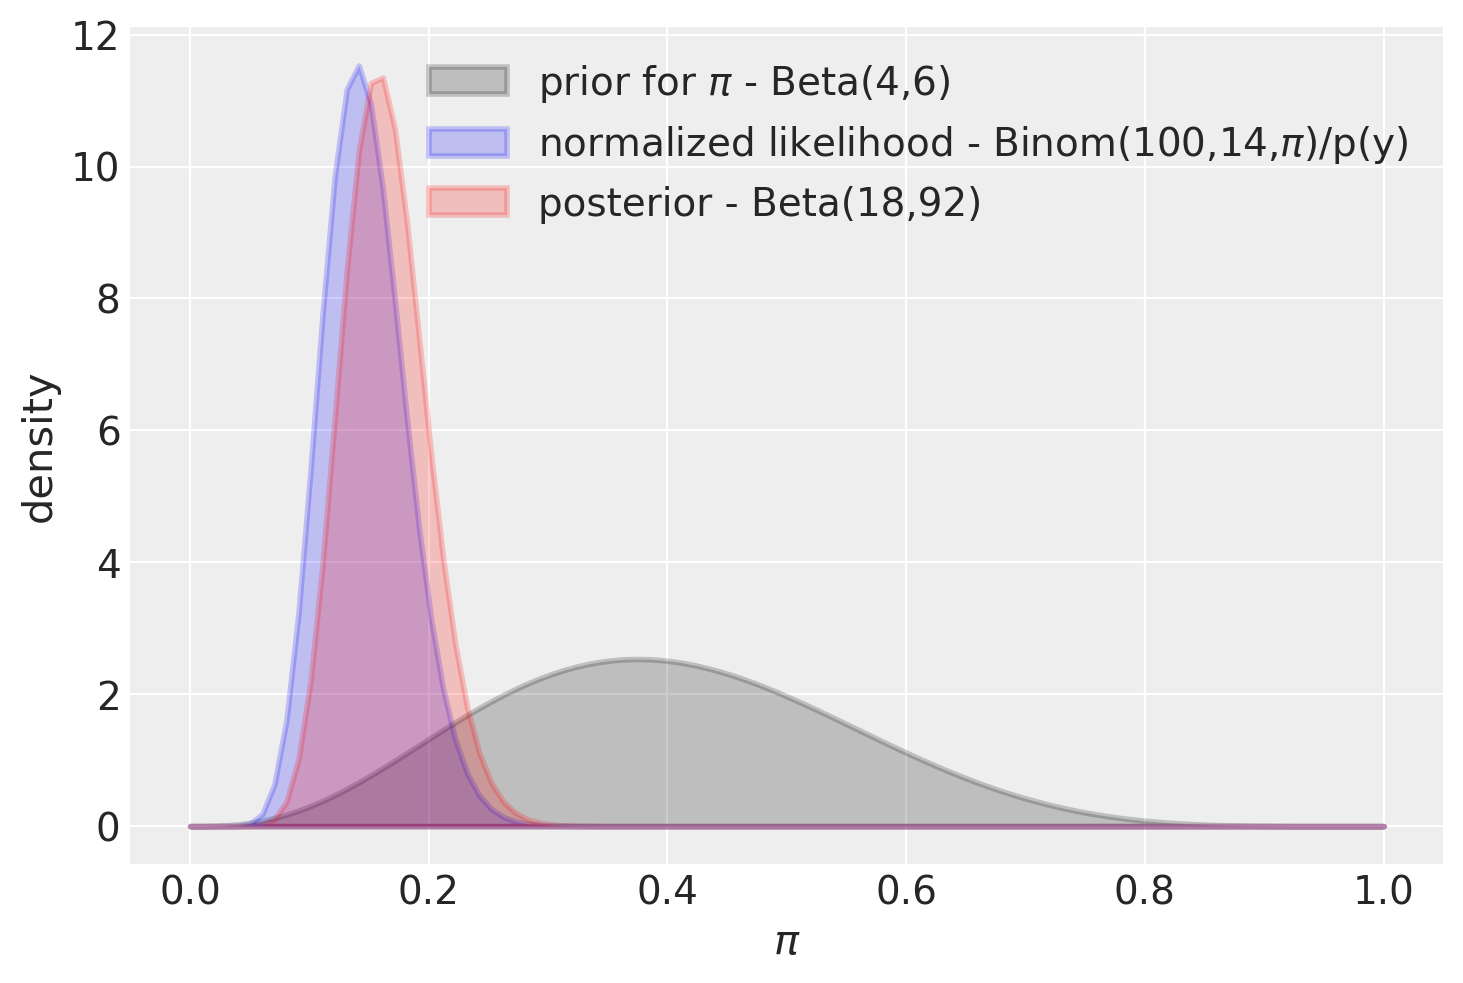

<IPython.core.display.Javascript object>

In [21]:
plot_beta_binomial(a=4, b=6, y=14, n=100)

There are three common tasks in posterior analysis: estimation, hypothesis testing, and prediction. For example, what is our estimate of $\pi$? Does our model support the claim that fewer than 20% of museum artists are Gen X or younger? If we sample 20
more museum artists, how many do we predict will be Gen X or younger?

## 8.1 Posterior estimation

**Quiz**

What best describes our posterior estimate of $\pi$?<P>
a. Roughly 16% of museum artists are Gen X or younger.<P>
b. It is most likely the case that roughly 16% of museum artists are Gen X or younger, but that gure could plausibly be anywhere between 9% and 26%.<P>

<U>Answer</U>: B

Consider Figure 8.2, which illustrates our $Beta(18, 92)$ posterior for $\pi$ (left) alongside a different posterior adopted by another analyst, $Beta(4, 16)$ (right). Though their different data resulted in a different posterior, the central tendency in both cases is similar. Thus, the other analyst's best guess of $\pi$ agrees with ours: roughly 16-17% of represented artists are Gen X or younger. However, reporting only this shared "best guess" would make our two posteriors seem misleadingly similar. In fact, whereas we are quite confident that the representation of younger artists is between 10% and 24%, the other analyst will indicate a much wider range for the representation of younger artists, from 6% to 40%. 

![](fig-8-02-beta_dist_18_92.png)<P>
_Figure 8.2_

So, posterior estimates should reflect both the central tendency and variability in  $\pi$. The posterior mean and mode of  $\pi$ provide quick summaries of the central tendency.

$\mathbb{E}[Beta(18,92)] = \frac{18}{18+92} \approx 0.164$ <P>
$Mode[Beta(18,92)] = \frac{18-1}{18+92-2} \approx 0.157$ <P>

However, to report both the central tendency and variability in $\pi$, we can report a range of posterior plausible $\pi$ values. This range is called a **posterior credible interval** (CI) for $\pi$. For example, we noticed earlier that the proportion of museum artists that are Gen X or younger is most likely between 10% and 24%. This range captures the more plausible values of $\pi$ while eliminating the more extreme and unlikely scenarios (Figure 8.2). In fact, 0.1 and 0.24 are the
2.5-th and 97.5-th posterior percentiles, i.e., the 0.025-th and 0.975-th posterior quantiles, and thus mark the middle 95% of posterior plausible $\pi$ values. We can confirm these $Beta(18,92)$ posterior quantile calculations using:

In [23]:
percents = beta.ppf([0.025, 0.975], 18, 92)

print(percents)

[0.10090844 0.23792856]


<IPython.core.display.Javascript object>

The resulting 95% credible interval for  $\pi$, (0.101, 0.238), is represented by the shaded region in Figure 8.2 left. Whereas the area under the entire posterior pdf is 1, the area of this shaded region, and hence the fraction of  $\pi$ values that fall into this region, is 0.95. This reveals an intuitive interpretation of the CI. There is a 95% posterior probability that somewhere between 10% and 24% of museum artists are Gen X or younger:

$P(\pi \in (0.101,0.238) \mid Y=14) = \int_{0.101}^{0.238} f(\pi \mid y) d\pi = 0.95$

In constructing the CI above, we used a "middle 95%" approach. This is not our only option. The first tweak we could make is to the 95% credible level. For example, a middle 50% CI, ranging from the 25th to the 75th percentile, would draw our focus to a smaller range of some of the more plausible $\pi$ values. Though a 95% level is a common choice among practitioners, it is somewhat arbitrary and simply ingrained through decades of tradition.

Consider a second possible tweak to our construction of the CI: it is not necessary to report the middle 95% of posterior plausible values.  We could also consider forming a 95% CI for $\pi$ using not the middle, but the 95% of posterior values with the highest posterior density.

In [25]:
percents = beta.ppf([0.25, 0.75], 18, 92)

print(percents)

[0.1388414  0.18621971]


<IPython.core.display.Javascript object>

## 8.2 Posterior hypothesis testing 

### 8.2.1 One-sided tests

Hypothesis testing is another common task in posterior analysis. For example, suppose we read an article claiming that fewer than 20% of museum artists are Gen X or younger. 

To evaluate exactly how plausible it is that $\pi < 0.2$, we can calculate the posterior probability of this scenario, $P(\pi<0.2\mid Y=14)$. This posterior probability is represented by the shaded area under the posterior pdf in Figure 8.4 and, mathematically, is calculated by integrating the posterior pdf on the range from 0 to 0.2:

$P(\pi < 0.2 \mid Y=14) = \int_{0}^{0.2} f(\pi \mid y) d\pi$

![](fig-8-04-beta_dist_18_92.png)<P>
_Figure 8.4_

We will not calculate the integral here. Instead, we obtain the result from the $Beta(18,92)$ posterior probability. The result reveals a strong evidence in favor of our claim: there is a roughly 84.9% posterior chance that Gen Xers account for fewer than 20% of modern art museum artists.

In [30]:
posterior_prob = beta.cdf(0.2, 18, 92)
print(posterior_prob)

0.848985555953253


<IPython.core.display.Javascript object>

Text(0.5, 1.0, 'Posterior')

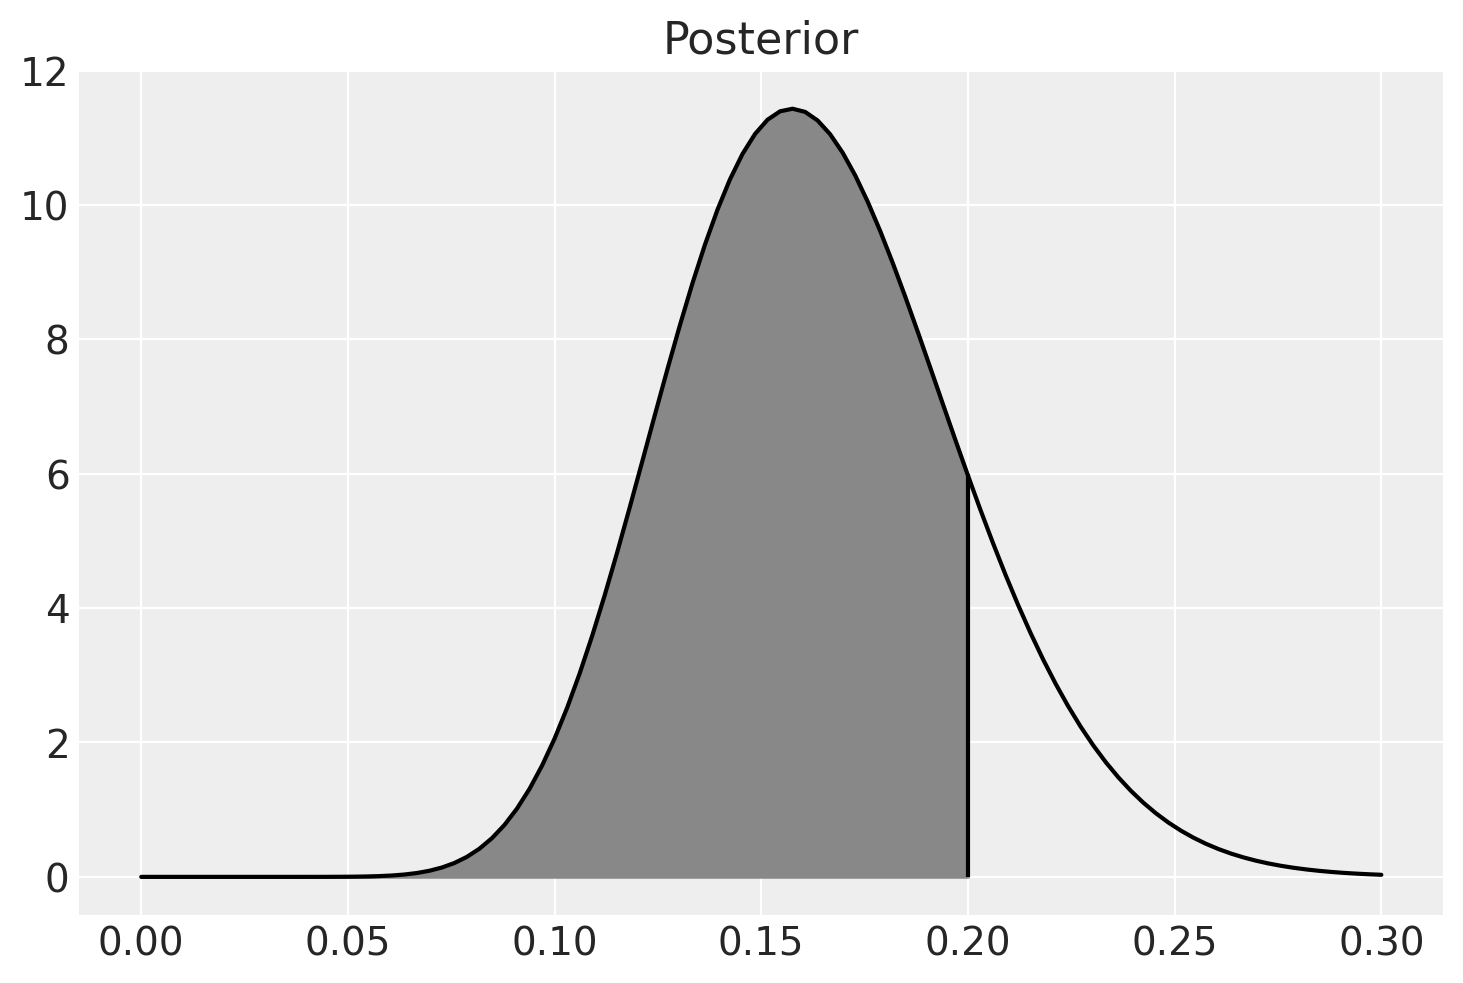

<IPython.core.display.Javascript object>

In [34]:
fig, ax = plt.subplots(1, 1)
a, b = 18, 92
x    = np.linspace(0, 0.3, 100)
y    = beta.pdf(x, a, b)
ax.plot(x, y, "k")
ax.vlines(0.2, 0, 6, colors="k")
pt1 = 0
pt2 = 0.2
ptx = np.linspace(pt1, pt2, 100)
pty = beta.pdf(ptx, a, b)
ax.fill_between(ptx, pty, color='#888888')
ax.set_title("Posterior")

Though not always necessary, practitioners often formalize this procedure into a hypothesis testing framework. For example, we can frame our analysis as two competing hypotheses: the null hypothesis $H_0$ contends that at least 20% of museum artists are Gen X or younger (the status quo here) whereas the alternative hypothesis $H_a$ (our claim) contends that this value is below 20%. In mathematical notation:<P>

$H_0: \pi \geq 0.2$ <P>
$H_a: \pi < 0.2$ <P>

We have already calculated the posterior probability of the alternative hypothesis to be
$P(H_a \mid Y=14) = 0.849$. Thus, the posterior probability of the null hypothesis is
$P(H_0 \mid Y=14) = 0.151$. Putting these together, the posterior odds that $\pi < 0.2$ are roughly 5.62. That is, our posterior assessment is that $\pi$ is nearly 6 times more likely to be below 0.2 than to be above 0.2:

In [31]:
posterior_odds = posterior_prob / (1 - posterior_prob)
print(posterior_odds)

5.621883133844116


<IPython.core.display.Javascript object>

The prior probability that $\pi < 0.2$, calculated by the area under the $Beta(4,6)$ prior PDF $f(\pi)$ that falls below 0.2, is only 0.0856

$P(H_a) = \int_{0}^{0.2} f(\pi) d\pi \approx 0.0856$


In [32]:
prior_prob = beta.cdf(0.2, 4, 6)
print(prior_prob)

0.08564172800000006


<IPython.core.display.Javascript object>

Text(0.5, 1.0, 'Prior')

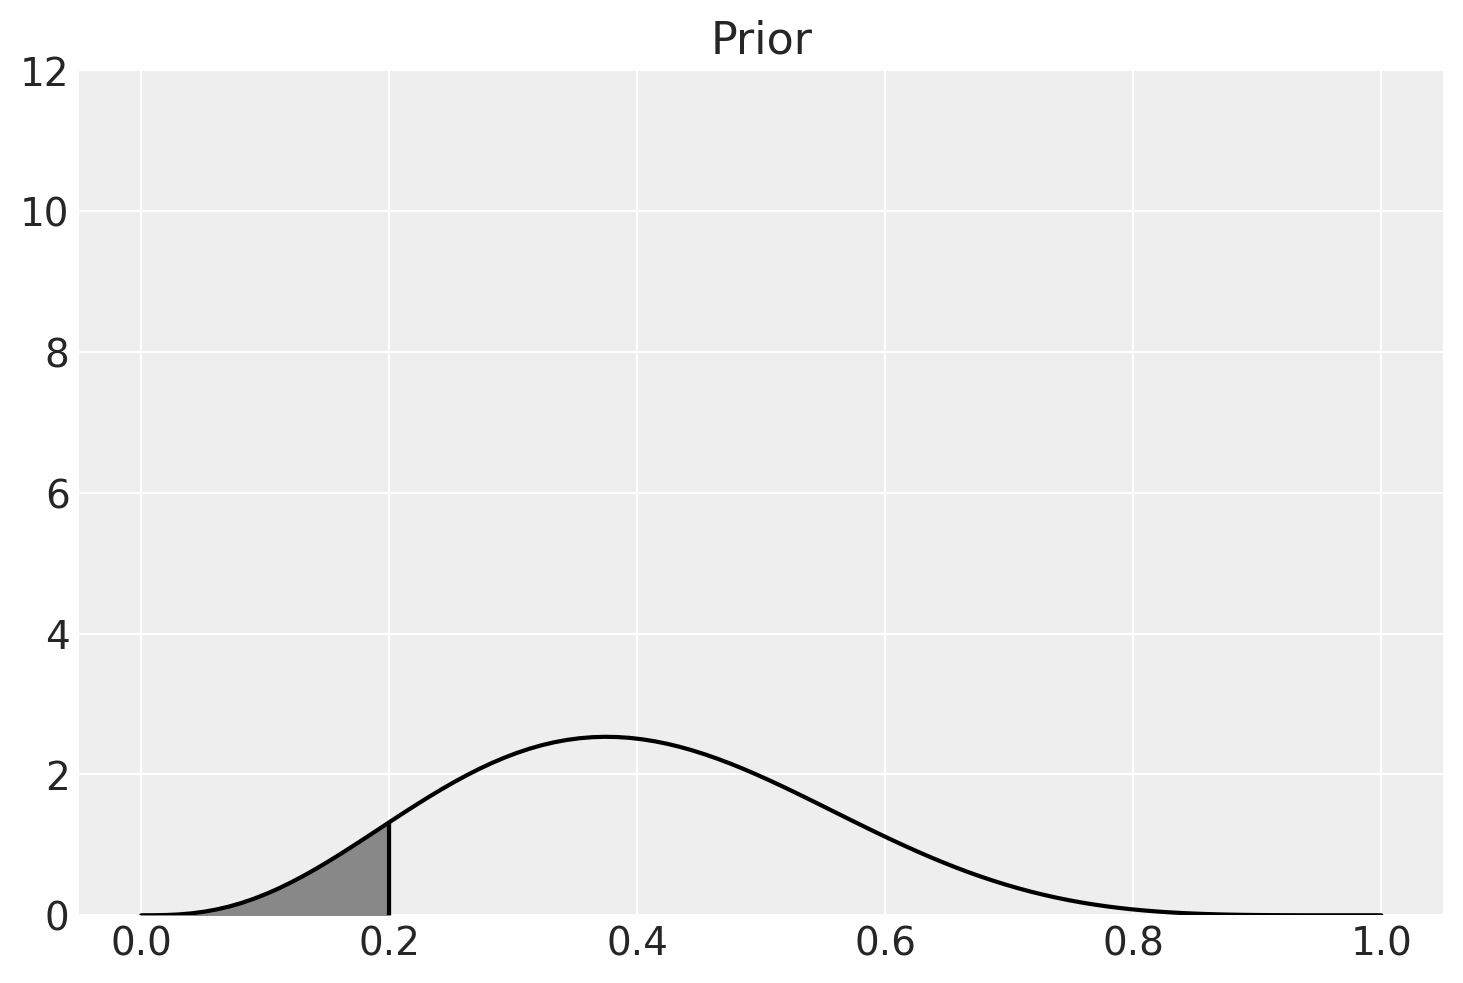

<IPython.core.display.Javascript object>

In [35]:
fig, ax = plt.subplots(1, 1)
a, b = 4, 6
x    = np.linspace(0, 1.0, 100)
y    = beta.pdf(x, a, b)
ax.plot(x, y, "k")
ax.vlines(0.2, 0, beta.pdf(0.2, a, b), colors="k")
plt.ylim([0, 12])

pt1 = 0
pt2 = 0.2
ptx = np.linspace(pt1, pt2, 100)
pty = beta.pdf(ptx, a, b)
ax.fill_between(ptx, pty, color='#888888')
ax.set_title("Prior")

Thus, the prior probability of the null hypothesis is $P(H_0) = 0.914$.

In [42]:
prior_odds = prior_prob / (1 - prior_prob)
print(f'Prior odds: {prior_odds: .4f}')

Prior odds:  0.0937


<IPython.core.display.Javascript object>

The Bayes Factor (BF) compares the posterior odds to the prior odds, and hence provides insight into just how much our understanding about Gen X representation evolved upon observing our sample data:

In [43]:
BF = posterior_odds / prior_odds
print(f'Bayes Factor: {BF: .4f}')

Bayes Factor:  60.0223


<IPython.core.display.Javascript object>

## 8.3 Posterior prediction

Beyond posterior estimation and hypothesis testing, a third common task in a posterior analysis
is to predict the outcome of new data $Y'$.

**Quiz**

Suppose we get our hands on data for 20 more artworks displayed at the museum. Based on the posterior understanding of $\pi$ that we have developed throughout this chapter, what number would you predict are done by artists that are Gen X or younger?


We can be tempted to answer "3". This is a very reasonable value to start since our best posterior guess was that roughly 16% of museum artists are Gen X or younger and 16% of 20 new artists is roughly 3. However, this calculation ignores two sources of potential variability in our prediction:<P>

* Sampling variability in the data<P>
* Posterior variability in $\pi$: 0.16 is not the only posterior plausible value of $\pi$, the underlying proportion of museum artists that are Gen X. Rather, our 95% posterior credible interval indicated that $\pi$ might be anywhere between roughly 0.1 and 0.24.

Let us specify these concepts with some math. First, let $Y'=y'$ be the yet unknown number of
the 20 new artworks that are done by Gen X or younger artists, where $y'$ can be any number of
artists in $\{0, 1, \dots, 20\}$. Conditioned on $\pi$, the randomness or sampling variability in $Y'$ can be modeled by $Y' \mid \pi \sim Binom(20, \pi)$ with PDF:

$f(Y' \mid \pi) = P(Y'=y'\mid \pi) = C_{y'}^{20}\pi^{y'}(1-\pi)^{20-y'}$

Thus, the random outcome of $y'$ depends upon $\pi$, which too can vary: $\pi$ might be any value
between 0 and 1.

For an overall understanding of how many of the next 20 artists will be Gen X, we must combine the sampling variability in $Y'$ with the posterior variability in $\pi$. To this end, weighting
$f(y' mid \pi)$ by posterior PDF $f(\pi \mid y=14)$ captures the chance of observing $Y'= y'$ Gen Xers for a given $\pi$ while taking into account the posterior plausibility of that $\pi$ value:

$f(y \mid \pi) f(\pi \mid y=14)$  (eq. 8.3)


Putting this all together, the posterior predictive model of $Y'$, the number of the 20 new artists that are Gen X, takes into account both the sampling variability in $Y'$ and posterior variability in $\pi$. Specifically, the posterior predictive pmf calculates the overall chance of observing $Y'=y'$ across all possible $\pi$ from 0 to 1 by averaging across eq.8.3, the chance of observing $Y' = y'$ for any given $\pi$:

$f(y' \mid y=14) = P(Y'=y' \mid Y=y) = \int_{0}^{1} f(y' \mid \pi) f(\pi \mid y=14) d\pi$

**Posterior predictive model**

Let $Y'$ denote a new outcome of variable $Y$. Further, let PDF $f(y' \mid \pi)$ denote the dependence of $Y'$ on $\pi$ and posterior PDF $f(\pi \mid y)$ denote the posterior plausibility of $\pi$ given the original data $Y=y$. Then the posterior predictive model for $Y'$ has PDF:

$f(y' \mid y) = \int f(y' \mid \pi) f(\pi \mid y) d\pi$

In words, the overall chance of observing $Y' = y′'$ weights the chance of observing this
outcome under any possible $\pi$ ($f(y'\mid \pi)$) by the posterior plausibility of $\pi$ ($f (\pi \mid y)$).


## 8.4 Posterior analysis with MCMC

### 8.4.1 Posterior simulation

Below we run four parallel Markov chains of $\pi$ for 10000 iterations each. After puting away the first 5000 iterations of each chain, we end up with four separate Markov chain samples
of size 5000, $\{\pi^{(1)}, \pi^{(2)}, \dots, \pi^{(5000)}\}$, or a combined Markov chain sample size of 20000.

In [146]:
num_samples = 5000
n_tune      = 5000
n_chains    = 4
seed        = 84735

with pm.Model() as model:
    pi = pm.Beta("pi", 4, 6)
    y  = pm.Binomial("y", n=100, p=pi, observed=14)
    trace = pm.sample(
        num_samples,
        tune                 = n_tune,
        chains               = n_chains,
        return_inferencedata = True,
        random_seed          = seed,
    )
    ppc = pm.sample_posterior_predictive(
        trace, random_seed=seed, extend_inferencedata=False
    )

Auto-assigning NUTS sampler...
INFO:pymc.sampling.mcmc:Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
INFO:pymc.sampling.mcmc:Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
INFO:pymc.sampling.mcmc:Multiprocess sampling (4 chains in 4 jobs)
NUTS: [pi]
INFO:pymc.sampling.mcmc:NUTS: [pi]


Sampling 4 chains for 5_000 tune and 5_000 draw iterations (20_000 + 20_000 draws total) took 2 seconds.
INFO:pymc.sampling.mcmc:Sampling 4 chains for 5_000 tune and 5_000 draw iterations (20_000 + 20_000 draws total) took 2 seconds.
Sampling: [y]
INFO:pymc.sampling.forward:Sampling: [y]


<IPython.core.display.Javascript object>

Check out the numerical and visual diagnostics in Figure 8.8. First, the randomness in the trace
plots (left), the agreement in the density plots of the four parallel chains (middle), and an Rhat value of effectively 1 suggest that our simulation is extremely stable. Further, our dependent chains are behaving "enough" like an independent sample. The autocorrelation, shown at right for just one chain, drops off quickly and the effective sample size ratio is satisfyingly high – our 20000 Markov chain values are as effective as 8900 independent samples (0.445 * 20000).

![](fig-8-08-mcmc-trace-plot-autocorr.png) <P>
_Figure 8.8_


array([[<Axes: title={'center': 'pi'}>, <Axes: title={'center': 'pi'}>]],
      dtype=object)

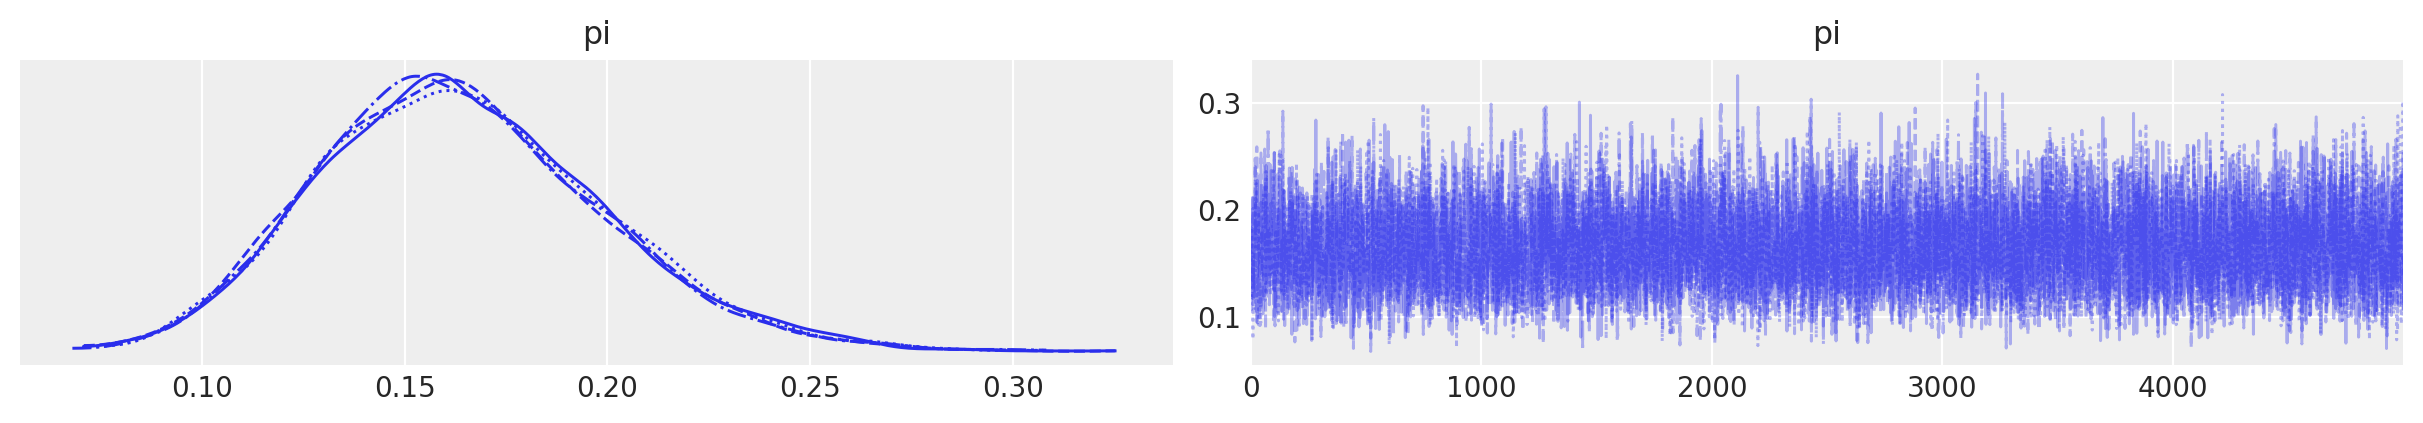

<IPython.core.display.Javascript object>

In [147]:
az.plot_trace(trace)

array([<Axes: title={'center': 'pi\n0'}>,
       <Axes: title={'center': 'pi\n1'}>,
       <Axes: title={'center': 'pi\n2'}>,
       <Axes: title={'center': 'pi\n3'}>], dtype=object)

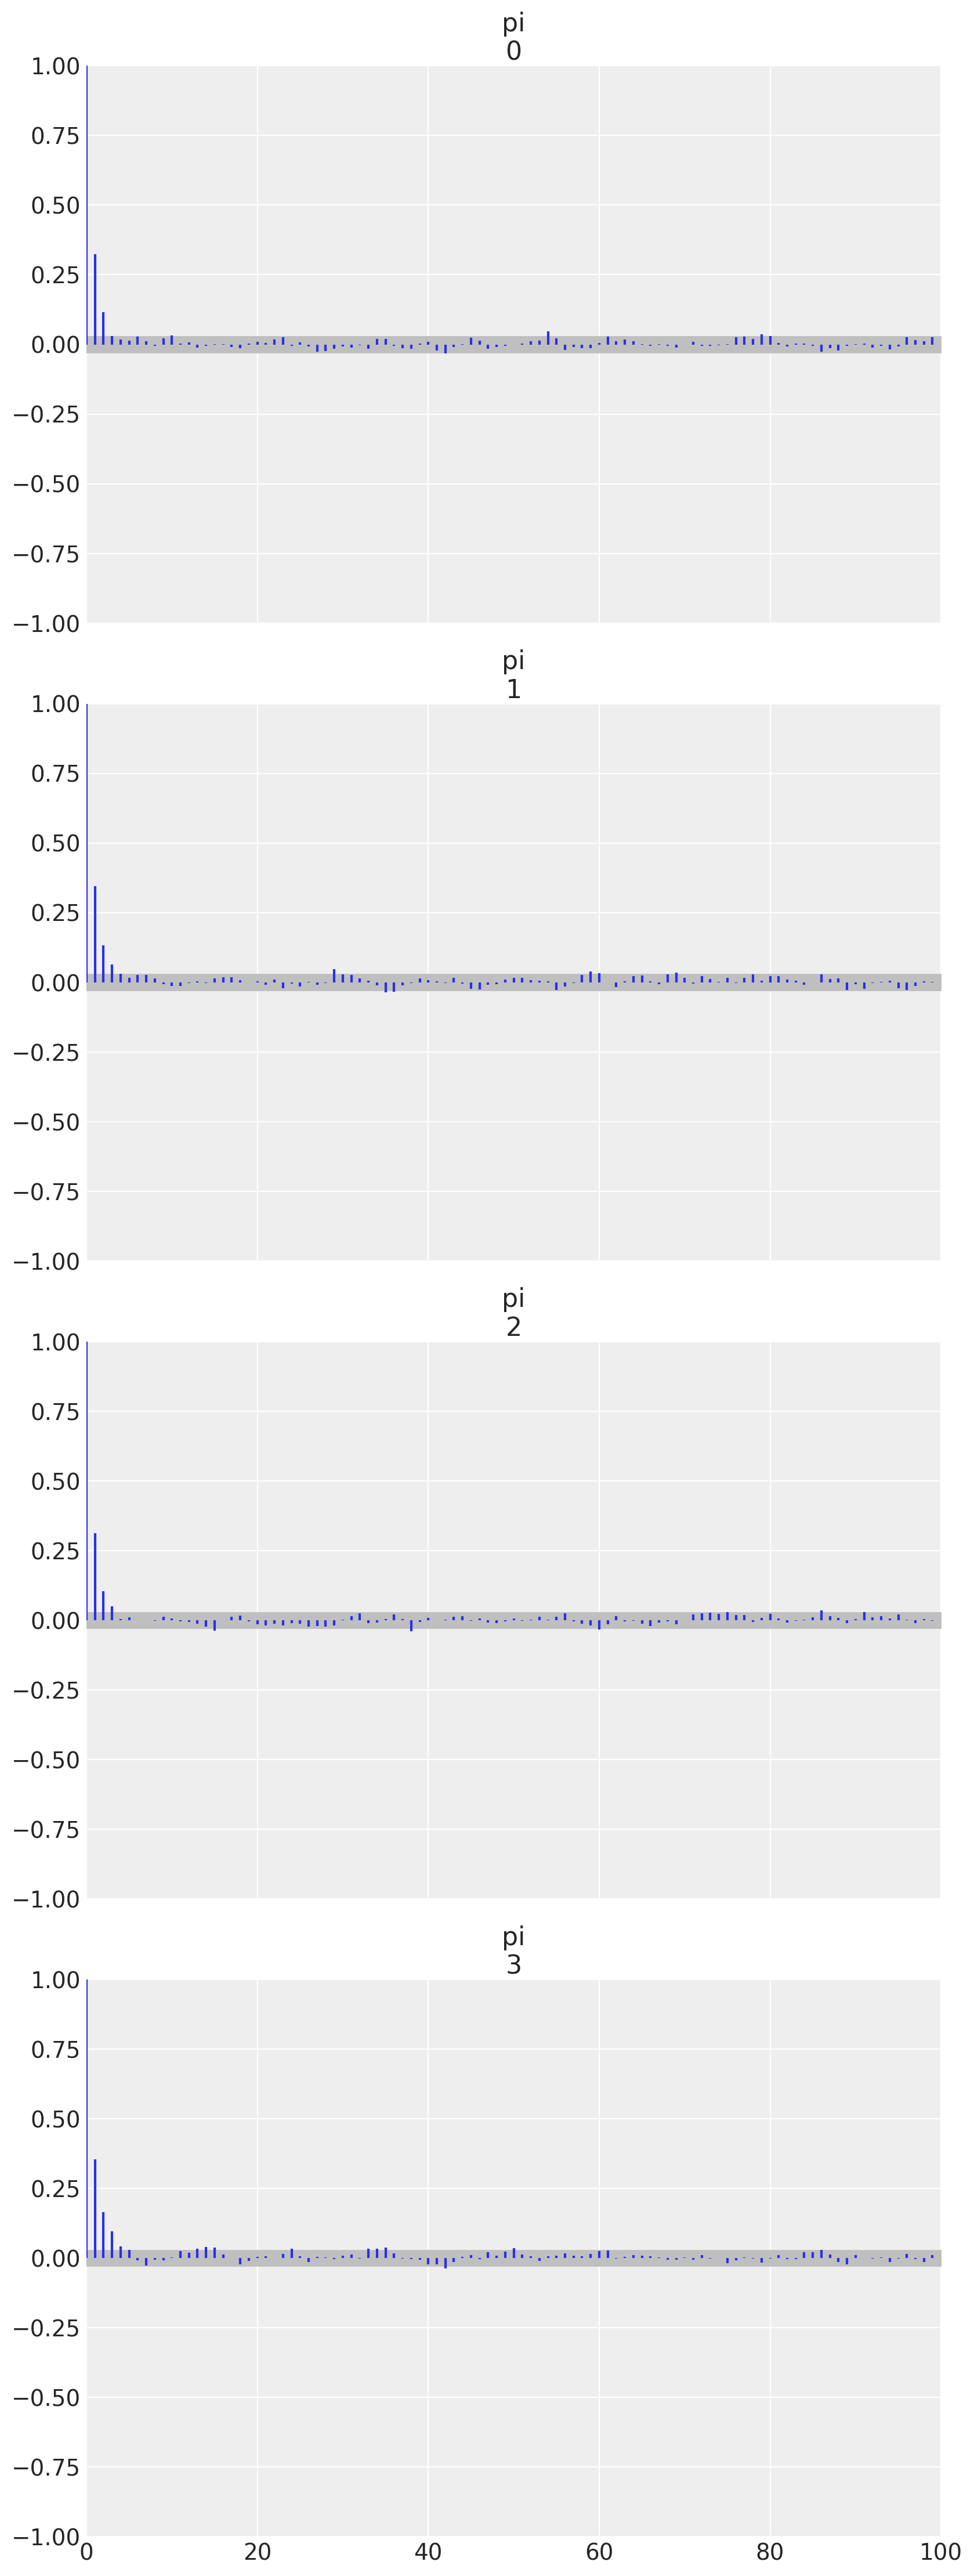

<IPython.core.display.Javascript object>

In [148]:
az.plot_autocorr(trace, grid=(4, 1))

In [149]:
pm.summary(trace)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
pi,0.164,0.035,0.099,0.228,0.0,0.0,8900.0,12656.0,1.0


<IPython.core.display.Javascript object>

In [150]:
# Compute R-hat

rhat = az.rhat(trace, var_names=['pi'], method='rank')
rhat = rhat.pi.data

# Compute the n_eff ratio

n_eff_ratio = az.ess(trace, var_names=['pi'], method='bulk', relative=True)
n_eff_ratio = n_eff_ratio.pi.data

print(f'R-hat:       {rhat: .4f}')
print(f'N_eff ratio: {n_eff_ratio: .4f}')

R-hat:        1.0003
N_eff ratio:  0.4450


<IPython.core.display.Javascript object>

### 8.4.2 Posterior estimation and hypothesis testing

We can now use the combined 20000 Markov chain values, with confidence, to approximate the $Beta(18, 92)$ posterior model of $\pi$. Indeed, Figure 8.9 con rms that the complete MCMC
approximation (right) closely mimics the actual posterior (left).


In [151]:
print(trace.posterior['pi'].data[0])
print(trace.posterior['pi'].data[1])
print(trace.posterior['pi'].data[2])
print(trace.posterior['pi'].data[3])

[0.19586952 0.19586952 0.16015091 ... 0.19256105 0.12687733 0.10751121]
[0.16269179 0.15116118 0.15604613 ... 0.3018418  0.10139507 0.15589758]
[0.19202452 0.17555117 0.13139561 ... 0.17915557 0.25478679 0.16211702]
[0.14079221 0.14079221 0.13882228 ... 0.15554164 0.12077801 0.1537843 ]


<IPython.core.display.Javascript object>

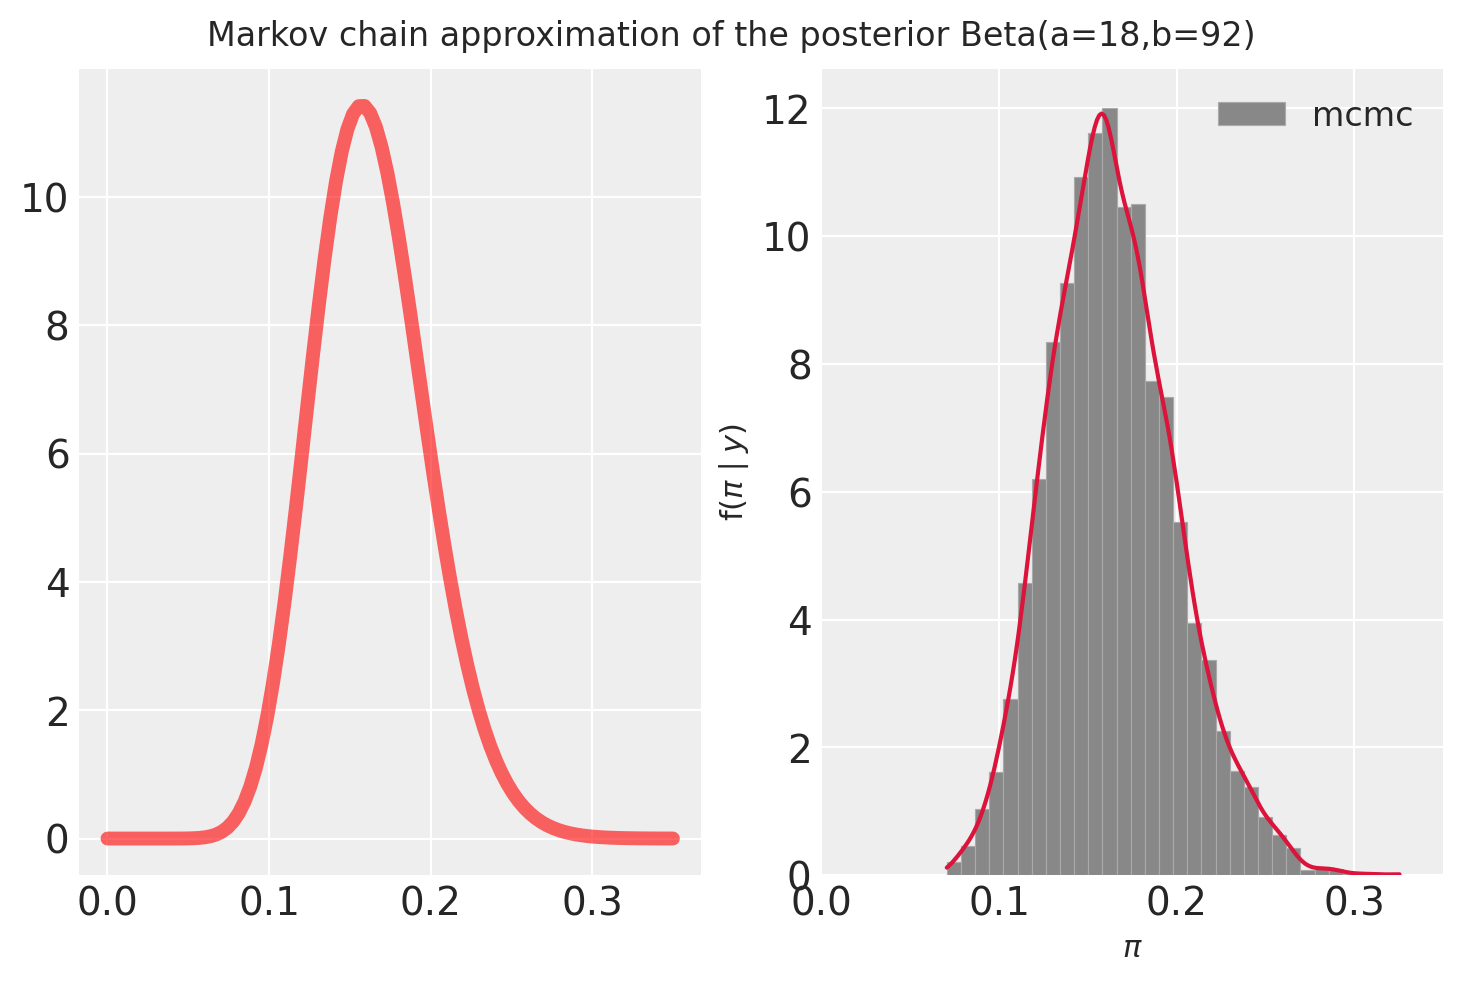

<IPython.core.display.Javascript object>

In [152]:
# Plot the actual posterior Beta(18,92)

fig, ax = plt.subplots(1, 2)

# Display the probability density function Beta(18,92)

a, b = 18, 92
x    = np.linspace(0, 0.35, 100)
y    = beta.pdf(x, a, b)
ax[0].plot(x, y, 'r-', lw=5, alpha=0.6, label='pdf')
#ax[0].vlines(0.2, 0, 6, colors="k")

# Plot the markov chain histogram

ax[1].set_xlim([x[0], x[-1]])
sns.histplot(
    ax=ax[1],
    data=trace.posterior['pi'].data[0], 
    stat='density', 
    bins=32, 
    kde=True, 
    discrete=False,
    facecolor='#888888', 
    edgecolor='#AAAAAA', 
    label='mcmc'
)
ax[1].lines[0].set_color('crimson')
ax[1].set_ylabel('f($\pi \mid y$)', fontsize=11)
ax[1].set_xlabel(r'$\pi$', fontsize=11)
fig.suptitle(f'Markov chain approximation of the posterior Beta(a={a},b={b})')
plt.legend(loc='upper right', fontsize= 12)
plt.show()

As such, we can approximate any feature of the $Beta(18, 92)$ posterior model by the corresponding feature of the Markov chain. For example, we can approximate the posterior
mean by the mean of the MCMC sample values, or approximate the 2.5-th posterior percentile
by the 2.5th percentile of the MCMC sample values.

In [153]:
# MCMC posterior approximation for the mean, stddev, median and percentiles
from scipy.stats import mode

func_dict = {
    "mean":   np.mean,
    "std":    np.std,
    "median": lambda x: np.percentile(x, 50.0),
    "2.5%":   lambda x: np.percentile(x,  2.5),
    "97.5%":  lambda x: np.percentile(x, 97.5),
}

mean = trace.posterior['pi'].data.mean()
print(f'MCMC trace mean:    {mean: .4f}')

mode_pi = mode(trace.posterior['pi'].data[0])
print(f'MCMC trace[0] mode: {mode_pi[0]: .4f}')
mode_pi = mode(trace.posterior['pi'].data[1])
print(f'MCMC trace[1] mode: {mode_pi[0]: .4f}')
mode_pi = mode(trace.posterior['pi'].data[2])
print(f'MCMC trace[2] mode: {mode_pi[0]: .4f}')
mode_pi = mode(trace.posterior['pi'].data[3])
print(f'MCMC trace[3] mode: {mode_pi[0]: .4f}')

pm.summary(trace, stat_funcs=func_dict, extend=False)

MCMC trace mean:     0.1638
MCMC trace[0] mode:  0.1597
MCMC trace[1] mode:  0.1416
MCMC trace[2] mode:  0.1726
MCMC trace[3] mode:  0.1774


,mean,std,median,2.5%,97.5%
pi,0.164,0.035,0.161,0.102,0.239


<IPython.core.display.Javascript object>

And the `mcmc_areas` function in the `bayesplot` package provides a visual complement:

![](fig-8-10-mcmc-areas.png) <P>
_Figure 8.10_

The previous MCMC trace summary reports the 2.5t-h and 97.5-th percentiles of the Markov chain values, 0.102 and 0.239, respectively. These form an approximate middle 95% credible interval for $\pi$, which is represented by the shaded region in the Figure 8.10. Further, the estimate reports that the median of our 20000 Markov chain values, and thus our approximation of the actual posterior median, is 0.161. This median is represented by the vertical line in the Figure 8.10. 

### 8.4.3 Posterior prediction

Finally, we can utilize our Markov chain values to approximate the posterior predictive model
of $Y'$, the number of the next 20 sampled artists that will be Gen X or younger. Recall that the posterior predictive model reflects two sources of variability:<P>

* **Sampling variability in the data**: $Y'$ might be any number of artists in $\{0, 1, \dots, 20\}$ and depends upon the underlying proportion of artists that are Gen X, $\pi$: $Y' \mid \pi \sim Binim(20, \pi)$.<P>
* **Posterior variability in** $\pi$: The collection of 20000 Markov chain $\pi$ values provides an approximate sense for the variability and range in plausible $\pi$ values.

To capture both sources of variability in posterior predictions $Y'$, we can use `scipy.stats.binom` to simulate one $Binom(20, \pi)$ outcome $Y'$ from each of the 20000 $\pi$ chain values. The resulting collection of 20000 predictions closely approximates the true posterior predictive distribution. It is most likely that 3 of the 20 artists will be Gen X or younger, though this gure might reasonably range between 0 and, say, 10:


In [171]:
# Make 20000 predictions using a Binom(20,pi) distribution, where
# each prediction uses a different 'pi' value from the MCMC trace

pi      = trace.posterior.pi.data
pi_size = pi.shape[0]*pi.shape[1]
pi      = np.reshape(pi, pi_size)

y_pred  = np.zeros(pi_size)

for i, p in enumerate(pi):  
    y_pred[i] = binom.rvs(20, p, size=1)[0]

<IPython.core.display.Javascript object>

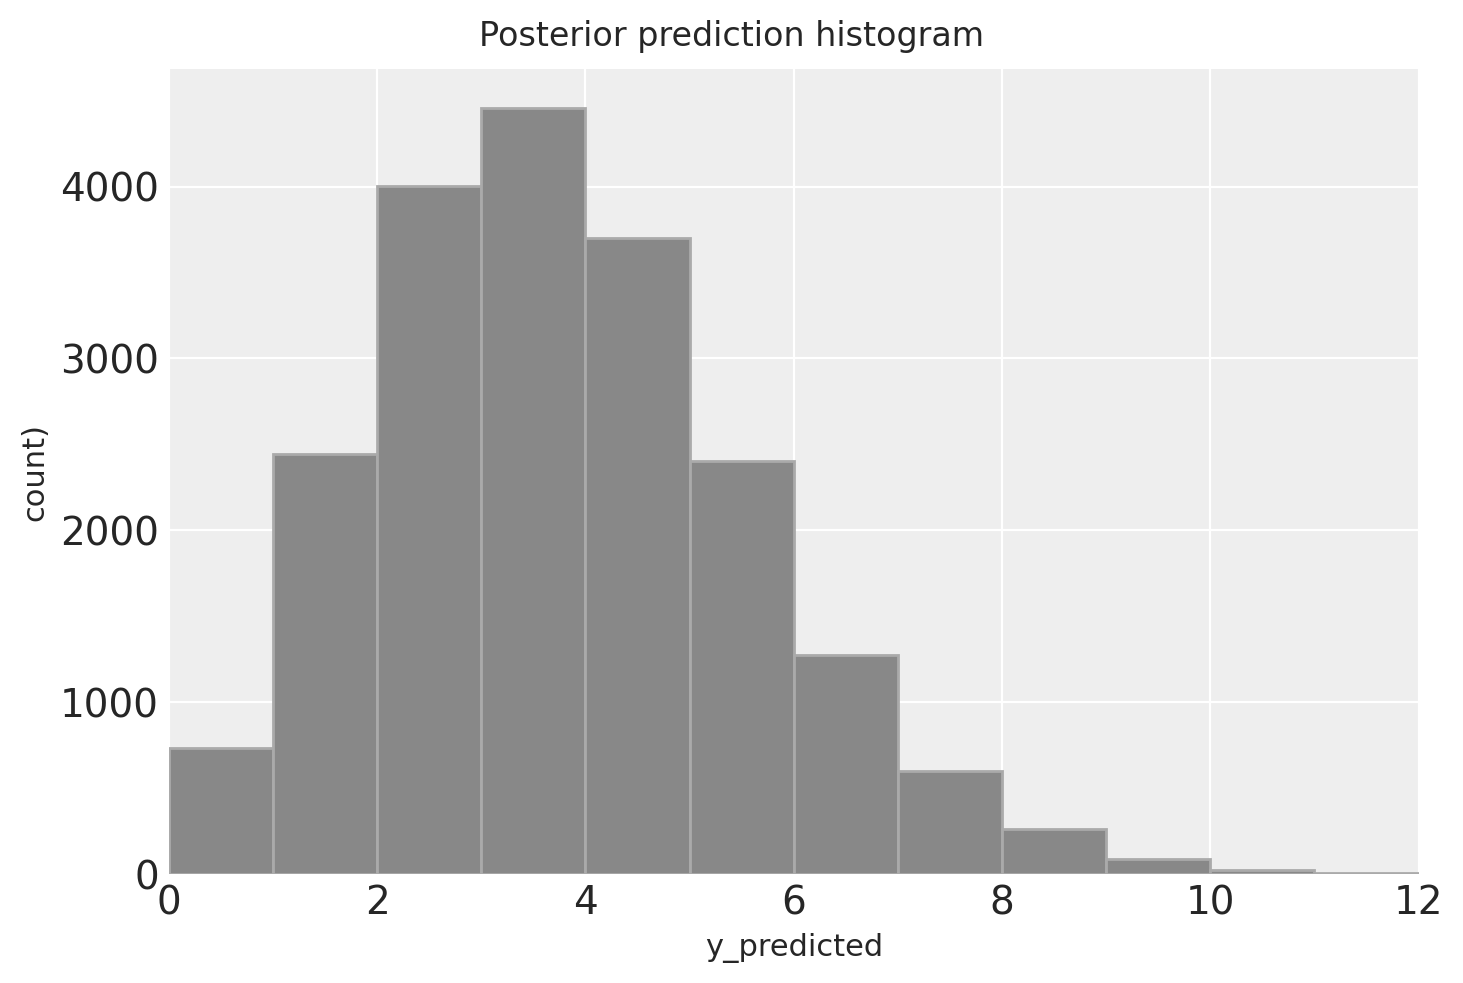

<IPython.core.display.Javascript object>

In [181]:
# Plot the histogram of the predictions

fig, ax = plt.subplots(1, 1)

x = np.linspace(0, 20, 100)

ax.set_xlim(0, 12)
sns.histplot(
    ax=ax,
    data=y_pred, 
    stat='count', 
    bins=13,
    kde=False, 
    discrete=False,
    facecolor='#888888', 
    edgecolor='#AAAAAA', 
    label='mcmc'
)
ax.set_ylabel('count)', fontsize=11)
ax.set_xlabel('y_predicted', fontsize=11)
fig.suptitle(f'Posterior prediction histogram')
plt.show()

We can also utilize the posterior predictive sample to approximate features of the actual posterior predictive model that were burdensome to specify mathematically. For example, we
can approximate the posterior mean prediction, $E(Y'\mid Y=14)$, and the more comprehensive
posterior prediction interval for Y′. To this end, we expect roughly 3 of the next 20 artists to be
Gen X or younger, but there's an 80% chance that this gure is somewhere between 1 and 6
artists:

In [188]:
# posterior predictive model -> posterior mean prediction

y_pred_mean = np.mean(y_pred)

# posterior predictive model -> 10% quantile

y_pred_10p = np.percentile(y_pred, 10.0)

# posterior predictive model -> 90% quantile

y_pred_90p = np.percentile(y_pred, 90.0)

print(f'Mean: {y_pred_mean:.3f}\n80% percentile: {y_pred_10p: .0f}-{y_pred_90p:.0f}')

Mean: 3.285
80% percentile:  1-6


<IPython.core.display.Javascript object>

In [189]:
watermark

Last updated: 2024-02-11T04:45:01.975610+00:00

Python implementation: CPython
Python version       : 3.11.7
IPython version      : 8.21.0

Compiler    : GCC 12.3.0
OS          : Linux
Release     : 6.5.0-17-generic
Machine     : x86_64
Processor   : x86_64
CPU cores   : 20
Architecture: 64bit



<IPython.core.display.Javascript object>